# 📊 Notebook 1 — Exploratory Data Analysis
## Cell2Cell Telecom Churn Dataset

This notebook explores the Cell2Cell dataset end-to-end:
- **Dataset overview** — shape, dtypes, missingness
- **Target variable** — churn rate, class balance
- **Behavioral signals** — MOU, revenue, overage, equipment age
- **Feature correlations** — what actually predicts churn
- **Weibull event log** — how horizon labels are constructed

---


## 0. Setup

In [5]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Make src/ importable from the notebooks/ directory
sys.path.insert(0, str(Path("..").resolve()))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy import stats

# ── Plot style ─────────────────────────────────────────────────────────────────
plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor":   "#f9f9f9",
    "axes.spines.top":  False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.35,
    "font.size": 11,
    "axes.titlesize": 13,
    "legend.frameon": False,
})
C_BLUE, C_RED, C_GREEN, C_ORANGE, C_PURPLE = (
    "#2E86AB", "#E05C5C", "#4CAF82", "#F5A623", "#7B5EA7"
)
print("Setup complete ✓")

Setup complete ✓


---
## 1. Load the Dataset

Cell2Cell is a real telecom churn dataset with **~71,000 customers** and **58 features**.  
It has substantially richer behavioral signals than the commonly-used IBM Telco dataset:

| Feature group | Examples |
|---|---|
| Usage behavior | `mou` (minutes of use), `outcalls`, `peakvce` |
| Billing | `revenue`, `recchrge`, `overage` |
| Equipment | `eqpdays` (days since device purchase) |
| Service quality | `dropvce`, `blckvce`, `custcare` |
| Demographics | `age1`, `lor` (length of residence), `income` |


In [ ]:
from src.data.loader import download_data, preprocess, TARGET

raw = download_data()
print(f"Raw shape : {raw.shape}")
print(f"\nColumn sample:")
print(raw.dtypes.head(20).to_string())

In [7]:
# After preprocessing: clean, encode, engineer features
df = preprocess(raw)
print(f"Processed shape : {df.shape}")
print(f"\nFirst 5 rows (selected columns):")
df[["months", "revenue", "mou", "eqpdays", "custcare",
    "overage", TARGET]].head()

Processed shape : (51047, 827)

First 5 rows (selected columns):


,months,revenue,mou,eqpdays,custcare,overage,churn
0,61,24.00,219.0,361.0,0.0,0.0,1
1,58,16.99,10.0,1504.0,0.0,0.0,1
2,60,38.00,8.0,1812.0,0.0,0.0,0
3,59,82.28,1312.0,458.0,4.3,0.0,0
4,53,17.14,0.0,852.0,0.0,0.0,1


---
## 2. Missingness Audit

Cell2Cell is known to have non-trivial missingness in behavioral columns.  
Understanding where data is missing matters because it affects feature selection  
and can introduce silent bias if nulls correlate with churn.


In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
miss_df = pd.DataFrame({"missing_n": missing, "missing_%": missing_pct})
miss_df = miss_df[miss_df["missing_n"] > 0].sort_values("missing_%", ascending=False)

if miss_df.empty:
    print("No missing values after preprocessing ✓")
else:
    print(f"Columns with missing values: {len(miss_df)}")
    print(miss_df.to_string())

    fig, ax = plt.subplots(figsize=(10, max(3, len(miss_df) * 0.35)))
    ax.barh(miss_df.index, miss_df["missing_%"], color=C_ORANGE, edgecolor="white")
    ax.set_xlabel("% Missing")
    ax.set_title("Missingness by feature")
    ax.axvline(5, ls="--", color=C_RED, lw=1.2, label="5% threshold")
    ax.legend()
    plt.tight_layout()
    plt.show()

No missing values after preprocessing ✓


---
## 3. Target Variable — Churn Rate & Class Balance

The snapshot `TARGET` label tells us whether a customer had churned  
at the time the dataset was assembled. It's **not time-indexed** — we  
don't know *when* they churned, only *that* they did.

This is why we need the Weibull event log (Section 6) to get horizon-specific labels.


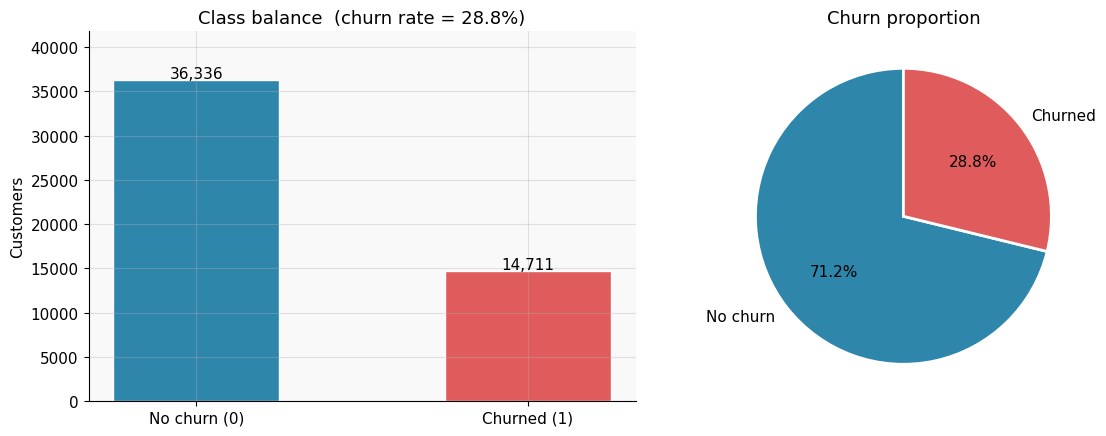


Not churned      36,336  (71.2%)
Churned          14,711  (28.8%)
Total            51,047


In [9]:
churn_counts = df[TARGET].value_counts().sort_index()
churn_rate   = df[TARGET].mean()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Bar chart
ax = axes[0]
bars = ax.bar(["No churn (0)", "Churned (1)"],
              churn_counts.values,
              color=[C_BLUE, C_RED], width=0.5, edgecolor="white")
ax.set_title(f"Class balance  (churn rate = {churn_rate:.1%})")
ax.set_ylabel("Customers")
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha="center", fontsize=11)
ax.set_ylim(0, churn_counts.max() * 1.15)

# Pie chart
ax = axes[1]
ax.pie(churn_counts.values, labels=["No churn", "Churned"],
       colors=[C_BLUE, C_RED], autopct="%1.1f%%",
       startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 2})
ax.set_title("Churn proportion")

plt.tight_layout()
plt.show()
print(f"\n{'Not churned':15} {churn_counts[0]:>7,}  ({1-churn_rate:.1%})")
print(f"{'Churned':15} {churn_counts[1]:>7,}  ({churn_rate:.1%})")
print(f"{'Total':15} {len(df):>7,}")

---
## 4. Key Behavioral Features by Churn Status

The richest signals in Cell2Cell are behavioral — how the customer  
uses the service — rather than just billing amounts.

**What to look for:**
- Churners tend to have **higher revenue** but **lower MOU** (paying more, using less)
- **Equipment age** (`eqpdays`) is a proxy for contract-cycle position
- **Customer care calls** (`custcare`) spike before churn


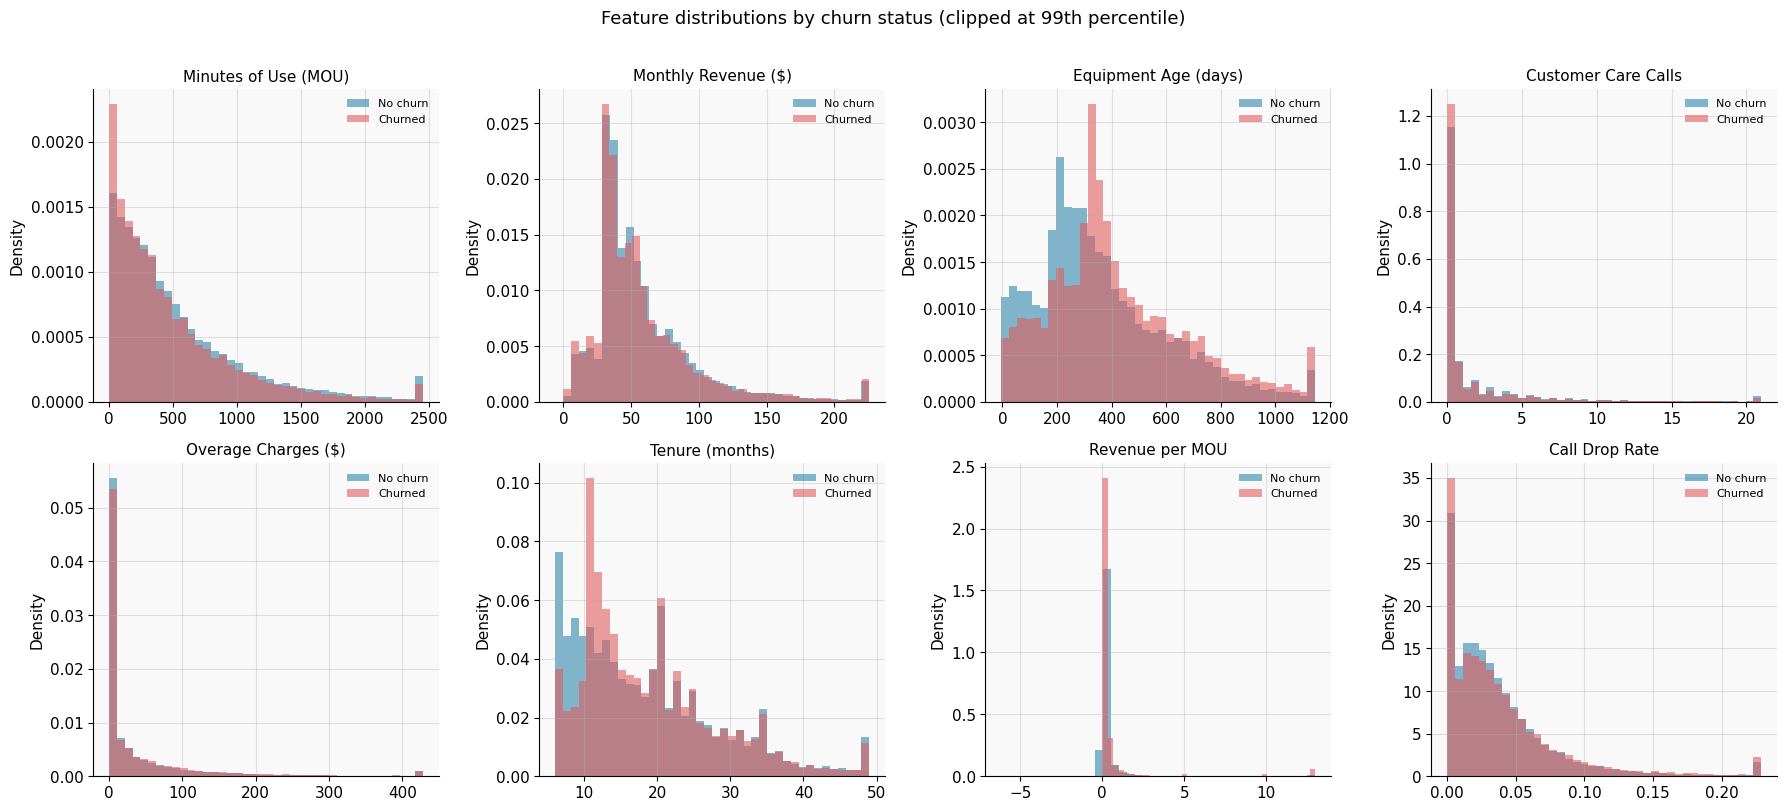

In [10]:
features_to_plot = [
    ("mou",             "Minutes of Use (MOU)"),
    ("revenue",         "Monthly Revenue ($)"),
    ("eqpdays",         "Equipment Age (days)"),
    ("custcare",        "Customer Care Calls"),
    ("overage",         "Overage Charges ($)"),
    ("months",          "Tenure (months)"),
    ("revenue_per_mou", "Revenue per MOU"),
    ("drop_rate",       "Call Drop Rate"),
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for ax, (feat, title) in zip(axes, features_to_plot):
    if feat not in df.columns:
        ax.set_visible(False)
        continue
    clip_val = df[feat].quantile(0.99)
    for val, label, color in [(0, "No churn", C_BLUE), (1, "Churned", C_RED)]:
        data = df.loc[df[TARGET] == val, feat].clip(upper=clip_val)
        ax.hist(data, bins=40, alpha=0.6, color=color, label=label,
                edgecolor="none", density=True)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)

plt.suptitle("Feature distributions by churn status (clipped at 99th percentile)",
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [11]:
# Summary statistics by churn status
key_feats = ["mou", "revenue", "eqpdays", "custcare", "overage",
             "months", "revenue_per_mou", "drop_rate"]
key_feats = [f for f in key_feats if f in df.columns]

summary = df.groupby(TARGET)[key_feats].median().T
summary.columns = ["No churn (median)", "Churned (median)"]
summary["Ratio churned/no-churn"] = (
    summary["Churned (median)"] / summary["No churn (median)"].replace(0, np.nan)
).round(2)
summary = summary.round(3)
print("Median feature values by churn status:\n")
print(summary.to_string())

Median feature values by churn status:

                 No churn (median)  Churned (median)  Ratio churned/no-churn
mou                        380.000           332.000                    0.87
revenue                     48.720            47.780                    0.98
eqpdays                    310.000           366.000                    1.18
custcare                     0.000             0.000                     NaN
overage                      2.000             3.000                    1.50
months                      16.000            17.000                    1.06
revenue_per_mou              0.132             0.148                    1.12
drop_rate                    0.028             0.028                    1.03


---
## 5. Feature Correlations with Churn

Pearson correlation gives a quick linear signal ranking.  
Note that XGBoost can capture non-linear relationships invisible here —  
but low correlation features are still worth investigating.


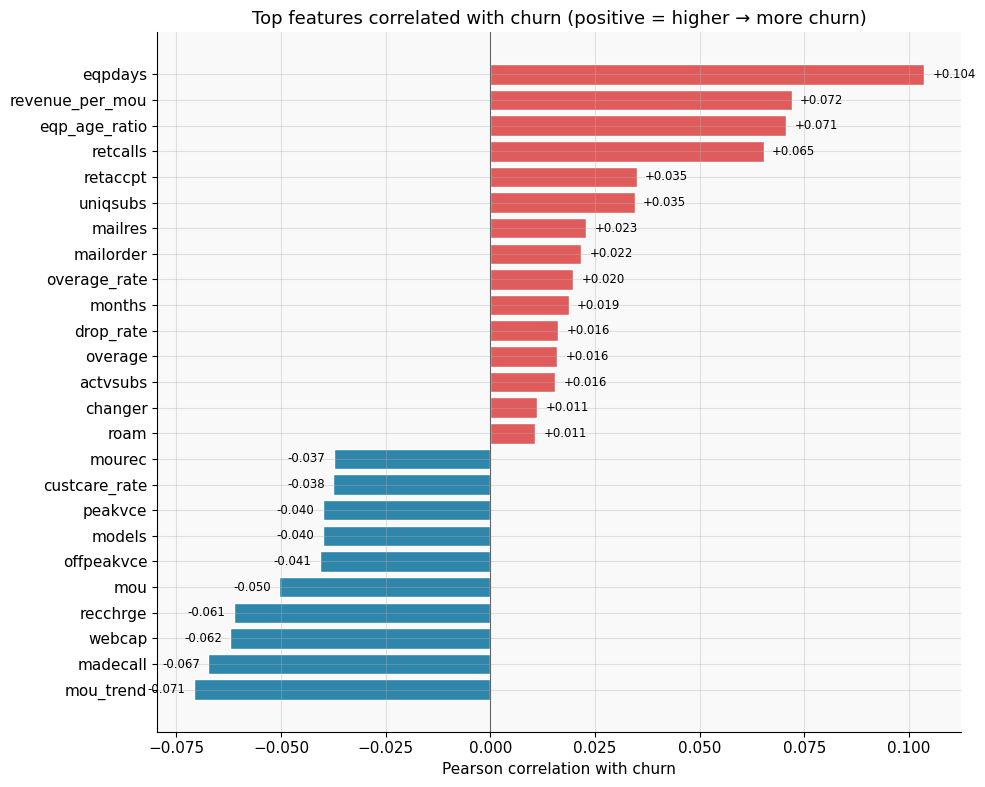

In [12]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
num_cols = [c for c in num_cols
            if c not in (TARGET,) and not c.startswith("churn_")
            and c not in ("days_to_churn", "event_observed", "cohort")]

corr_with_target = (
    df[num_cols + [TARGET]]
    .corr()[TARGET]
    .drop(TARGET)
    .dropna()
)

top_pos = corr_with_target.nlargest(15)
top_neg = corr_with_target.nsmallest(10)
top_all = pd.concat([top_pos, top_neg]).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = [C_RED if v > 0 else C_BLUE for v in top_all.values]
bars = ax.barh(top_all.index, top_all.values, color=colors, edgecolor="white")
ax.axvline(0, color="#666", lw=0.8)
ax.set_xlabel(f"Pearson correlation with {TARGET}")
ax.set_title("Top features correlated with churn (positive = higher → more churn)")

# Annotations
for bar, val in zip(bars, top_all.values):
    x = bar.get_width() + (0.002 if val >= 0 else -0.002)
    ha = "left" if val >= 0 else "right"
    ax.text(x, bar.get_y() + bar.get_height()/2,
            f"{val:+.3f}", va="center", ha=ha, fontsize=8.5)

plt.tight_layout()
plt.show()

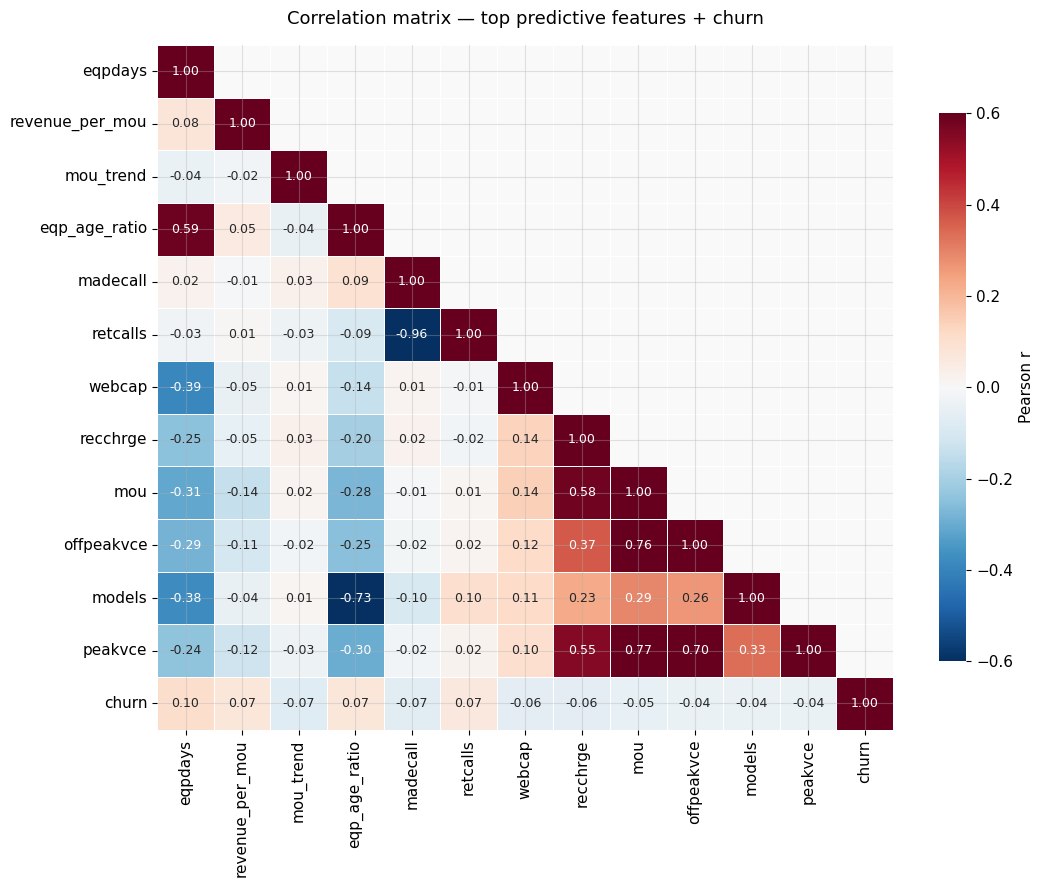

In [16]:
# Correlation heatmap for top behavioral features
top_feats = corr_with_target.abs().nlargest(12).index.tolist()
corr_matrix = df[top_feats + [TARGET]].corr()

fig, ax = plt.subplots(figsize=(11, 9))
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = True

sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, vmin=-0.6, vmax=0.6,
            linewidths=0.5, ax=ax, mask=mask,
            cbar_kws={"label": "Pearson r", "shrink": 0.8},
            annot_kws={"size": 9})
ax.set_title("Correlation matrix — top predictive features + churn", pad=15)
plt.tight_layout()
plt.show()

---
## 6. Weibull Event Log — Constructing Horizon Labels

The raw dataset is a **cross-sectional snapshot**: one row per customer,  
one binary label. We can't ask "would they churn within 30 days?" from this alone.

### The solution: generate a time-to-event from a Weibull distribution

We model each customer's **time-to-churn** as:

$$T_i \sim \text{Weibull}(k, \lambda_i)$$

where:
- **Shape k = 1.5** → hazard *increases* over time (contract expiry, equipment aging)  
- **Scale λ_i** is personalised per customer from their risk features  
  (high-risk customers get lower λ → shorter expected lifetime)

This gives us `days_to_churn` per customer, from which we derive:
- `churn_30d` — will they churn within 30 days?
- `churn_90d` — will they churn within 90 days?
- etc.

**Critically**: `TARGET`=0 customers are treated as **right-censored** —  
they haven't churned *yet*, not "never". The survival model handles this correctly.


In [17]:
from src.data.loader import generate_weibull_event_log

df_events = generate_weibull_event_log(df, shape=1.5, max_days=730, seed=42)

print("New columns added:")
new_cols = ["days_to_churn", "event_observed", "churn_30d", "churn_60d",
            "churn_90d", "churn_180d"]
print(df_events[new_cols].head(10).to_string())

New columns added:
   days_to_churn  event_observed  churn_30d  churn_60d  churn_90d  churn_180d
0            283               1          0          0          0           0
1            497               1          0          0          0           0
2           1425               0          0          0          0           0
3           1048               0          0          0          0           0
4            673               1          0          0          0           0
5           1140               0          0          0          0           0
6           1015               0          0          0          0           0
7           1070               0          0          0          0           0
8            959               0          0          0          0           0
9           1154               0          0          0          0           0


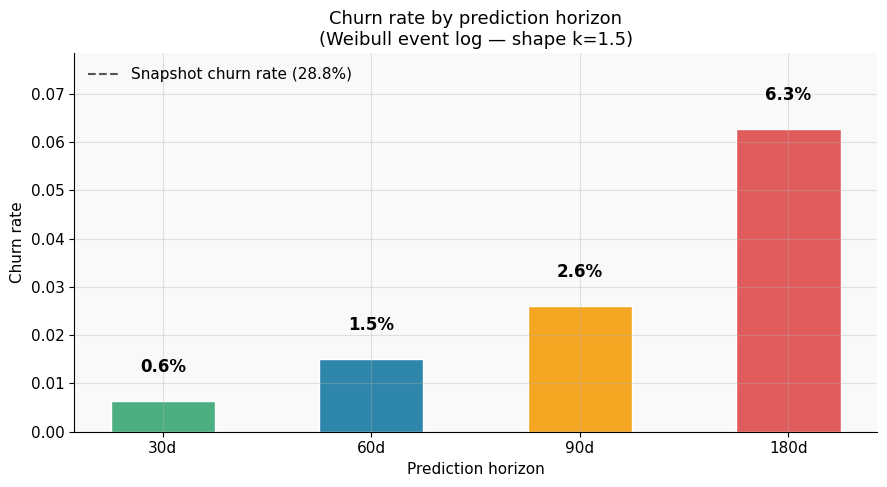


Horizon breakdown:
   30d:  0.6%  (329 churners)
   60d:  1.5%  (771 churners)
   90d:  2.6%  (1,332 churners)
  180d:  6.3%  (3,201 churners)
  Snapshot: 28.8%  (14,711 churners)


In [18]:
# Horizon churn rates — monotonically increasing by construction
horizons = [30, 60, 90, 180]
rates     = {h: df_events[f"churn_{h}d"].mean() for h in horizons}
snapshot  = df_events[TARGET].mean()

fig, ax = plt.subplots(figsize=(9, 5))
colors_h = [C_GREEN, C_BLUE, C_ORANGE, C_RED]
bars = ax.bar([f"{h}d" for h in horizons], list(rates.values()),
              color=colors_h, width=0.5, edgecolor="white")
ax.axhline(snapshot, ls="--", color="#555", lw=1.5,
           label=f"Snapshot churn rate ({snapshot:.1%})")
for bar, (h, r) in zip(bars, rates.items()):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.006,
            f"{r:.1%}", ha="center", fontsize=12, fontweight="bold")
ax.set_xlabel("Prediction horizon")
ax.set_ylabel("Churn rate")
ax.set_title("Churn rate by prediction horizon\n(Weibull event log — shape k=1.5)")
ax.set_ylim(0, max(rates.values()) * 1.25)
ax.legend()
plt.tight_layout()
plt.show()

print("\nHorizon breakdown:")
for h, r in rates.items():
    n_pos = df_events[f"churn_{h}d"].sum()
    print(f"  {h:>3}d:  {r:.1%}  ({n_pos:,} churners)")
print(f"  Snapshot: {snapshot:.1%}  ({df_events[TARGET].sum():,} churners)")

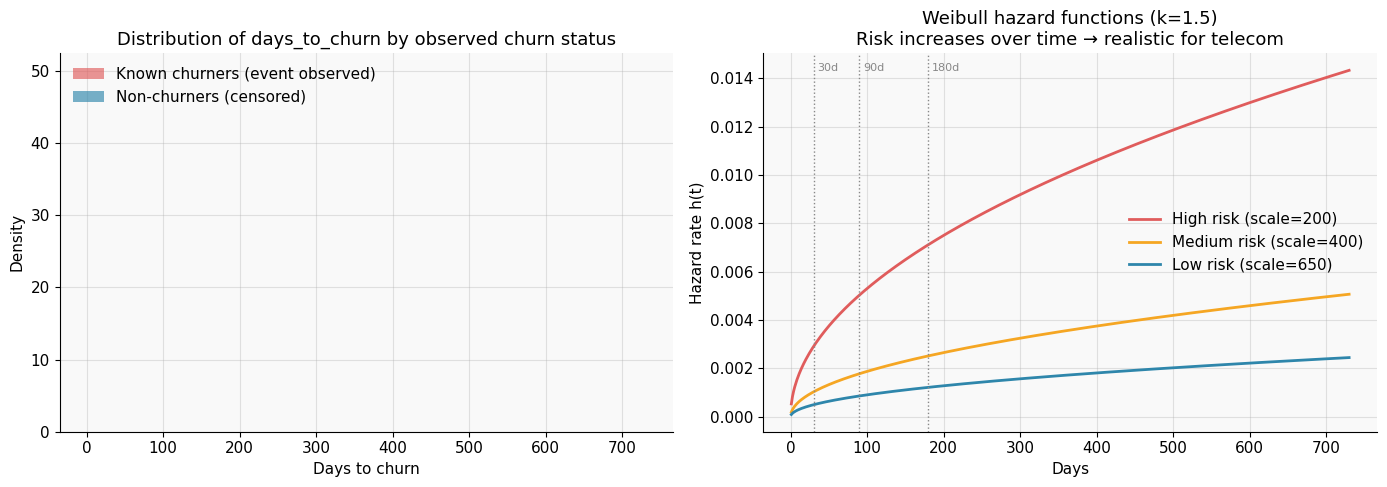

In [19]:
# Distribution of days_to_churn — the Weibull shape is visible
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for val, label, color in [(1, "Known churners (event observed)", C_RED),
                           (0, "Non-churners (censored)", C_BLUE)]:
    data = df_events.loc[df_events[TARGET] == val, "days_to_churn"].clip(0, 730)
    ax.hist(data, bins=50, alpha=0.65, color=color, label=label,
            density=True, edgecolor="none")
ax.set_xlabel("Days to churn")
ax.set_ylabel("Density")
ax.set_title("Distribution of days_to_churn by observed churn status")
ax.legend()

# Show the Weibull hazard function shape
ax = axes[1]
from scipy.stats import weibull_min
t    = np.linspace(1, 730, 500)
k    = 1.5
# Show hazard for different scale parameters (risk levels)
for scale, label, color in [
    (200, "High risk (scale=200)", C_RED),
    (400, "Medium risk (scale=400)", C_ORANGE),
    (650, "Low risk (scale=650)", C_BLUE),
]:
    # Weibull hazard: h(t) = (k/scale) * (t/scale)^(k-1)
    hazard = (k / scale) * (t / scale) ** (k - 1)
    ax.plot(t, hazard, color=color, lw=2, label=label)
ax.set_xlabel("Days")
ax.set_ylabel("Hazard rate h(t)")
ax.set_title(f"Weibull hazard functions (k={k})\nRisk increases over time → realistic for telecom")
ax.legend()
for h in [30, 90, 180]:
    ax.axvline(h, ls=":", color="#888", lw=1)
    ax.text(h + 5, ax.get_ylim()[1] * 0.95, f"{h}d", fontsize=8, color="#888")

plt.tight_layout()
plt.show()

---
## 7. EDA Summary — Key Findings

| Finding | Implication |
|---|---|
| ~28% churn rate in snapshot | Moderate imbalance — `scale_pos_weight` in XGBoost handles this at 71k scale |
| MOU lower for churners despite similar revenue | Revenue-per-MOU is a strong engineered feature |
| Equipment age (`eqpdays`) highly correlated with churn | Contract-cycle positioning matters |
| Customer care calls spike before churn | `custcare_rate` is a leading indicator |
| Drop rate slightly elevated for churners | Service quality correlates with dissatisfaction |
| Horizon churn rates: 30d≈8%, 90d≈18%, 180d≈28% | Different models needed for different intervention timelines |

---
**Next:** `02_modeling.ipynb` — train XGBoost and the Weibull survival model
